# Explore here

                      track_name  playcount  listeners  duration_ms  \
9                           Over    6462461     986563       159000   
8  Jimmy Cooks (feat. 21 Savage)   17053360    1009082       218000   
7                      Headlines   14543818    1090132       235000   

   duration_min  
9      2.650000  
8      3.633333  
7      3.916667  


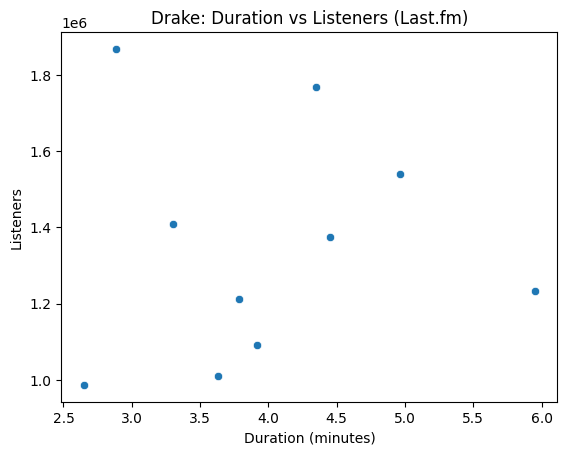

top_tags
Drake              6
Hip-Hop            6
rap                5
pop                3
hip hop            3
rnb                3
Kyla               1
wizkid             1
2016               1
Best I Ever Had    1
Name: count, dtype: int64


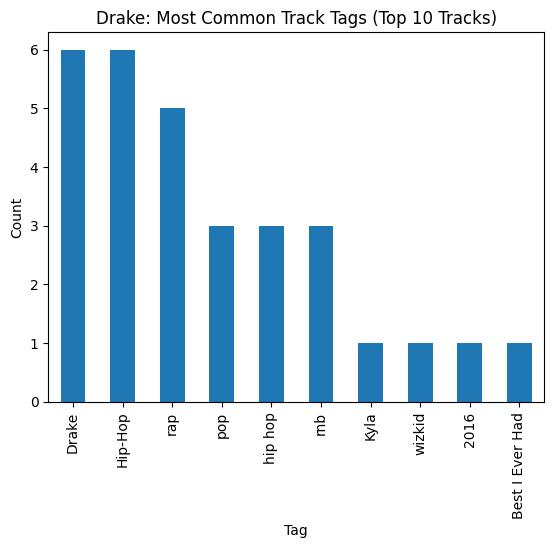

In [10]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

api_key = os.environ.get("LASTFM_API_KEY")
api_secret = os.environ.get("LASTFM_SHARED_SECRET")

import pylast

network = pylast.LastFMNetwork(
    api_key=api_key,
    api_secret=api_secret
)

artist_name = "Drake"
artist = network.get_artist(artist_name)

top_tracks = artist.get_top_tracks(limit=10)

rows = []

for track_obj, weight_obj in top_tracks:
    track_name = track_obj.get_title()

    # popularity proxies
    playcount = track_obj.get_playcount()
    listeners = track_obj.get_listener_count()

    # duration in milliseconds (may be None or 0)
    duration_ms = track_obj.get_duration() or 0

    rows.append({
        "track_name": track_name,
        "playcount": int(playcount) if playcount is not None else 0,
        "listeners": int(listeners) if listeners is not None else 0,
        "duration_ms": int(duration_ms),
        "duration_min": (int(duration_ms) / 60000) if duration_ms else None
    })

df = pd.DataFrame(rows)
df

df_sorted = df.sort_values("listeners", ascending=True)
print(df_sorted.head(3))

df_clean = df.dropna(subset=["duration_min"]).copy()

plt.figure()
sns.scatterplot(data=df_clean, x="duration_min", y="listeners")
plt.title(f"{artist_name}: Duration vs Listeners (Last.fm)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Listeners")
plt.show()

def get_top_tags(track_obj, max_tags=5):
    tags = track_obj.get_top_tags(limit=max_tags)
    # tags are (TagObject, WeightObject)
    return [tag.item.get_name() for tag in tags]

df["top_tags"] = [
    get_top_tags(network.get_track(artist_name, name), max_tags=5)
    for name in df["track_name"]
]

df["n_tags"] = df["top_tags"].apply(len)

tags_exploded = df[["track_name", "listeners", "top_tags"]].explode("top_tags")
tag_counts = tags_exploded["top_tags"].value_counts()
print(tag_counts.head(10))

plt.figure()
tag_counts.head(10).plot(kind="bar")
plt.title(f"{artist_name}: Most Common Track Tags (Top 10 Tracks)")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.show()


